In [1]:
import os, cv2, numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

print("TF version:", tf.__version__)
tf.config.list_physical_devices('GPU')

2026-04-22 03:21:21.476020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776828081.715535      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776828081.783262      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776828082.341987      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776828082.342035      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776828082.342038      22 computation_placer.cc:177] computation placer alr

TF version: 2.19.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [2]:
# ─── Config ──────────────────────────────────────────────────────────────────
IMG_SIZE      = 224
NUM_CLASSES   = 37
BATCH_SIZE    = 16
EPOCHS        = 150
LR            = 1e-4
IOU_THRESHOLD = 0.5          # IoU >= 0.5 → correct bbox prediction

USE_TXT_ANNOTATIONS = False

IMAGE_DIR        = Path("/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images")
ANNOTATIONS_XML  = Path("/kaggle/input/datasets/ggez690/a4-annotations/annotations/xmls")
ANNOTATIONS_TXT  = Path("/kaggle/input/datasets/ggez690/a4-annotations/annotations")
TRIMAPS_DIR      = Path("/kaggle/input/datasets/ggez690/a4-annotations/annotations/trimaps")

# Loss weights
BBOX_LOSS_WEIGHT  = 1.0
CLASS_LOSS_WEIGHT = 1.0

In [3]:
# ─── Build class map from XML filenames ──────────────────────────────────────
class_to_id = {}
for xml_path in ANNOTATIONS_XML.glob("*.xml"):
    class_name = "_".join(xml_path.stem.split("_")[:-1])
    if class_name not in class_to_id:
        class_to_id[class_name] = len(class_to_id)

id_to_class = {v: k for k, v in class_to_id.items()}
print(f"Classes found: {len(class_to_id)}")
print("Sample classes:", list(class_to_id.keys())[:5])

Classes found: 37
Sample classes: ['staffordshire_bull_terrier', 'saint_bernard', 'Birman', 'British_Shorthair', 'leonberger']


In [4]:
# ─── Annotation parsers ──────────────────────────────────────────────────────

def parse_xml(xml_path):
    """Pascal VOC XML → [xmin, ymin, xmax, ymax] normalised to [0,1]."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size   = root.find('size')
    orig_w = int(size.find('width').text)
    orig_h = int(size.find('height').text)
    obj    = root.find('object')
    if obj is None:
        return None, None, None
    bbox = obj.find('bndbox')
    xmin = int(float(bbox.find('xmin').text))
    ymin = int(float(bbox.find('ymin').text))
    xmax = int(float(bbox.find('xmax').text))
    ymax = int(float(bbox.find('ymax').text))
    xmin = max(0.0, min(xmin / orig_w, 1.0))
    ymin = max(0.0, min(ymin / orig_h, 1.0))
    xmax = max(0.0, min(xmax / orig_w, 1.0))
    ymax = max(0.0, min(ymax / orig_h, 1.0))
    return [xmin, ymin, xmax, ymax], orig_w, orig_h

def parse_txt_yolo(txt_path):
    """YOLO format -> corners [xmin, ymin, xmax, ymax] normalised to [0,1]."""
    with open(txt_path) as f:
        line = f.readline().strip()
    if not line:
        return None
    parts = line.split()
    cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
    xmin = max(0.0, cx - bw / 2)
    ymin = max(0.0, cy - bh / 2)
    xmax = min(1.0, cx + bw / 2)
    ymax = min(1.0, cy + bh / 2)
    return [xmin, ymin, xmax, ymax]

In [ ]:
train_images, train_boxes, train_labels = [], [], []
test_images,  test_boxes,  test_labels  = [], [], []
skipped = 0

print("Scanning images to split into XML (Train/Val) and Trimap (Test)...")

for img_path in IMAGE_DIR.glob("*.jpg"):
    img_name   = img_path.stem
    class_name = "_".join(img_name.split("_")[:-1])

    if class_name not in class_to_id:
        skipped += 1
        continue

    xml_path = ANNOTATIONS_XML / (img_name + ".xml")

    if xml_path.exists():
        box, orig_w, orig_h = parse_xml(xml_path)
        if box is None: 
            skipped += 1; continue

        img = cv2.imread(str(img_path))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        train_images.append(img)
        train_boxes.append(box)
        train_labels.append(class_to_id[class_name])

    else:
        trimap_path = TRIMAPS_DIR / (img_name + ".png")
        if not trimap_path.exists():
            skipped += 1; continue

        mask = cv2.imread(str(trimap_path), cv2.IMREAD_GRAYSCALE)
        if mask is None: 
            skipped += 1; continue

        coords = np.argwhere(mask == 1)
        if len(coords) == 0: 
            skipped += 1; continue

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        orig_h, orig_w = mask.shape

        xmin = max(0.0, min(x_min / orig_w, 1.0))
        ymin = max(0.0, min(y_min / orig_h, 1.0))
        xmax = max(0.0, min(x_max / orig_w, 1.0))
        ymax = max(0.0, min(y_max / orig_h, 1.0))

        if xmax <= xmin or ymax <= ymin:
            skipped += 1; continue

        img = cv2.imread(str(img_path))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        test_images.append(img)
        test_boxes.append([xmin, ymin, xmax, ymax])
        test_labels.append(class_to_id[class_name])

X_tr_val = np.array(train_images, dtype=np.float32) / 255.0
yb_tr_val = np.array(train_boxes,  dtype=np.float32)
yl_tr_val = np.array(train_labels, dtype=np.int32)

X_test = np.array(test_images, dtype=np.float32) / 255.0
yb_test = np.array(test_boxes,  dtype=np.float32)
yl_test = np.array(test_labels, dtype=np.int32)

print(f"Train/Val samples (XML)  : {len(X_tr_val)}")
print(f"Test samples (Trimaps)   : {len(X_test)}")
print(f"Skipped files            : {skipped}")

Scanning images to split into XML (Train/Val) and Trimap (Test)...


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


Train/Val samples (XML)  : 3686
Test samples (Trimaps)   : 3688
Skipped files            : 16


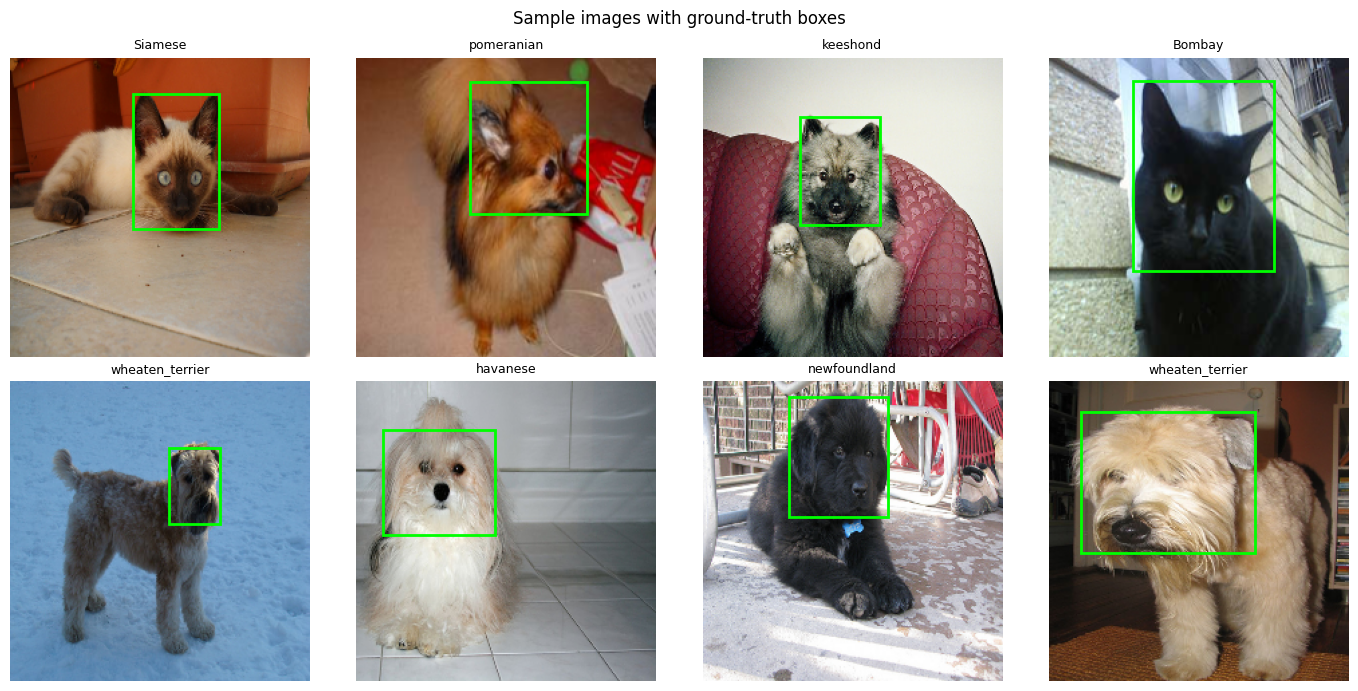

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
idx  = np.random.choice(len(X_tr_val), 8, replace=False)

for i, ix in enumerate(idx):
    img = X_tr_val[ix]; box = yb_tr_val[ix]; lbl = yl_tr_val[ix]
    axes[i].imshow(img)
    h, w = IMG_SIZE, IMG_SIZE
    rect = patches.Rectangle(
        (box[0]*w, box[1]*h), (box[2]-box[0])*w, (box[3]-box[1])*h,
        linewidth=2, edgecolor='lime', facecolor='none')
    axes[i].add_patch(rect)
    axes[i].set_title(id_to_class[lbl], fontsize=9)
    axes[i].axis('off')

plt.suptitle("Sample images with ground-truth boxes", fontsize=12)
plt.tight_layout(); plt.show()

In [7]:
# ─── Train / Val split (90 / 10 of the XML data) ──────────────────────────────
X_tr, X_val, yb_tr, yb_val, yl_tr, yl_val = train_test_split(
    X_tr_val, yb_tr_val, yl_tr_val, test_size=0.1, random_state=42)

print(f"Train={len(X_tr)}  Val={len(X_val)}  Test={len(X_test)} (Bonus Generated)")

Train=3317  Val=369  Test=3688 (Bonus Generated)


In [8]:
# ─── Dual-output model ───────────────────────────────────────────────────────
reg = regularizers.l2(1e-4)
inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=reg)(inp)
x = layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
x = layers.MaxPooling2D(2)(x);  x = layers.BatchNormalization()(x)

x = layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
x = layers.MaxPooling2D(2)(x);  x = layers.BatchNormalization()(x)

x = layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
x = layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
x = layers.MaxPooling2D(2)(x);  x = layers.BatchNormalization()(x)

x = layers.Conv2D(256, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
x = layers.Conv2D(256, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
x = layers.MaxPooling2D(2)(x);  x = layers.BatchNormalization()(x)

shared = layers.GlobalAveragePooling2D()(x)
shared = layers.Dense(512, activation='relu', kernel_regularizer=reg)(shared)
shared = layers.Dropout(0.5)(shared)

# ── BBox head ────────────────────────────────────────────────────────────────
bbox_out = layers.Dense(128, activation='relu')(shared)
bbox_out = layers.Dropout(0.3)(bbox_out)
bbox_out = layers.Dense(4, activation='sigmoid', name='bbox')(bbox_out)

# ── Classification head ───────────────────────────────────────────────────────
cls_out = layers.Dense(128, activation='relu')(shared)
cls_out = layers.Dropout(0.3)(cls_out)
cls_out = layers.Dense(NUM_CLASSES, activation='softmax', name='cls')(cls_out)

model = keras.Model(inputs=inp, outputs={'bbox': bbox_out, 'cls': cls_out},
                    name="PetDetector_DualHead")
model.summary()

I0000 00:00:1776828236.486228      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776828236.492344      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "PetDetector_DualHead"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        512 │ max_pooling2d_2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │    295,168 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 14, 14,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │      1,024 │ max_pooling2d_3[

 Total params: 1,442,377 (5.50 MB)

 Trainable params: 1,441,417 (5.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
# ─── Custom losses & metrics ─────────────────────────────────────────────────

def smooth_l1_loss(y_true, y_pred):
    """Smooth-L1 (Huber) loss — robust for bbox regression."""
    diff = tf.abs(y_true - y_pred)
    return tf.reduce_mean(tf.where(diff < 1.0, 0.5 * diff**2, diff - 0.5))

def iou_metric(y_true, y_pred):
    """Continuous mean IoU — used to monitor training progress."""
    x1 = tf.maximum(y_true[:, 0], y_pred[:, 0])
    y1 = tf.maximum(y_true[:, 1], y_pred[:, 1])
    x2 = tf.minimum(y_true[:, 2], y_pred[:, 2])
    y2 = tf.minimum(y_true[:, 3], y_pred[:, 3])
    inter = tf.maximum(0.0, x2-x1) * tf.maximum(0.0, y2-y1)
    area_t = (y_true[:,2]-y_true[:,0]) * (y_true[:,3]-y_true[:,1])
    area_p = (y_pred[:,2]-y_pred[:,0]) * (y_pred[:,3]-y_pred[:,1])
    union  = area_t + area_p - inter
    return tf.reduce_mean(inter / (union + 1e-7))

In [10]:
# ─── Compile ─────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss={
        'bbox': smooth_l1_loss,
        'cls' : 'sparse_categorical_crossentropy',
    },
    loss_weights={
        'bbox': BBOX_LOSS_WEIGHT,
        'cls' : CLASS_LOSS_WEIGHT,
    },
    metrics={
        'bbox': [iou_metric],
        'cls' : ['accuracy'],
    }
)

In [11]:
# ─── Training ────────────────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_pet_localization.keras',
        monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.CSVLogger('training_log.csv'),
]

history = model.fit(
    X_tr,
    {'bbox': yb_tr, 'cls': yl_tr},
    validation_data=(X_val, {'bbox': yb_val, 'cls': yl_val}),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
)

Epoch 1/150


I0000 00:00:1776828247.949679      75 service.cc:152] XLA service 0x7a4098089de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776828247.949728      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776828247.949735      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776828249.073746      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-22 03:24:13.375708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 03:24:13.526735: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 03:24:14.958135: E external/local_xl

  1/208 ━━━━━━━━━━━━━━━━━━━━ 1:11:42 21s/step - bbox_iou_metric: 0.0101 - bbox_loss: 0.0501 - cls_accuracy: 0.0000e+00 - cls_loss: 3.7129 - loss: 3.8757

I0000 00:00:1776828263.356554      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - bbox_iou_metric: 0.1130 - bbox_loss: 0.0277 - cls_accuracy: 0.0359 - cls_loss: 3.6675 - loss: 3.8079

2026-04-22 03:24:42.060073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 03:24:42.208066: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 03:24:42.474416: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 03:24:42.618262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 03:24:43.497646: E external/local_xla/xla/stream_

208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - bbox_iou_metric: 0.1134 - bbox_loss: 0.0277 - cls_accuracy: 0.0359 - cls_loss: 3.6674 - loss: 3.8077
Epoch 1: val_loss improved from inf to 3.79287, saving model to best_pet_localization.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 54s 162ms/step - bbox_iou_metric: 0.1138 - bbox_loss: 0.0276 - cls_accuracy: 0.0359 - cls_loss: 3.6673 - loss: 3.8075 - val_bbox_iou_metric: 0.3762 - val_bbox_loss: 0.0122 - val_cls_accuracy: 0.0244 - val_cls_loss: 3.6733 - val_loss: 3.7929 - learning_rate: 1.0000e-04
Epoch 2/150
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - bbox_iou_metric: 0.2849 - bbox_loss: 0.0152 - cls_accuracy: 0.0418 - cls_loss: 3.5806 - loss: 3.7084
Epoch 2: val_loss did not improve from 3.79287
208/208 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - bbox_iou_metric: 0.2849 - bbox_loss: 0.0152 - cls_accuracy: 0.0419 - cls_loss: 3.5805 - loss: 3.7083 - val_bbox_iou_metric: 0.3728 - val_bbox_loss: 0.0143 - val_cls_accuracy: 0.0244 - val_cls_loss: 3.7193 - val_loss

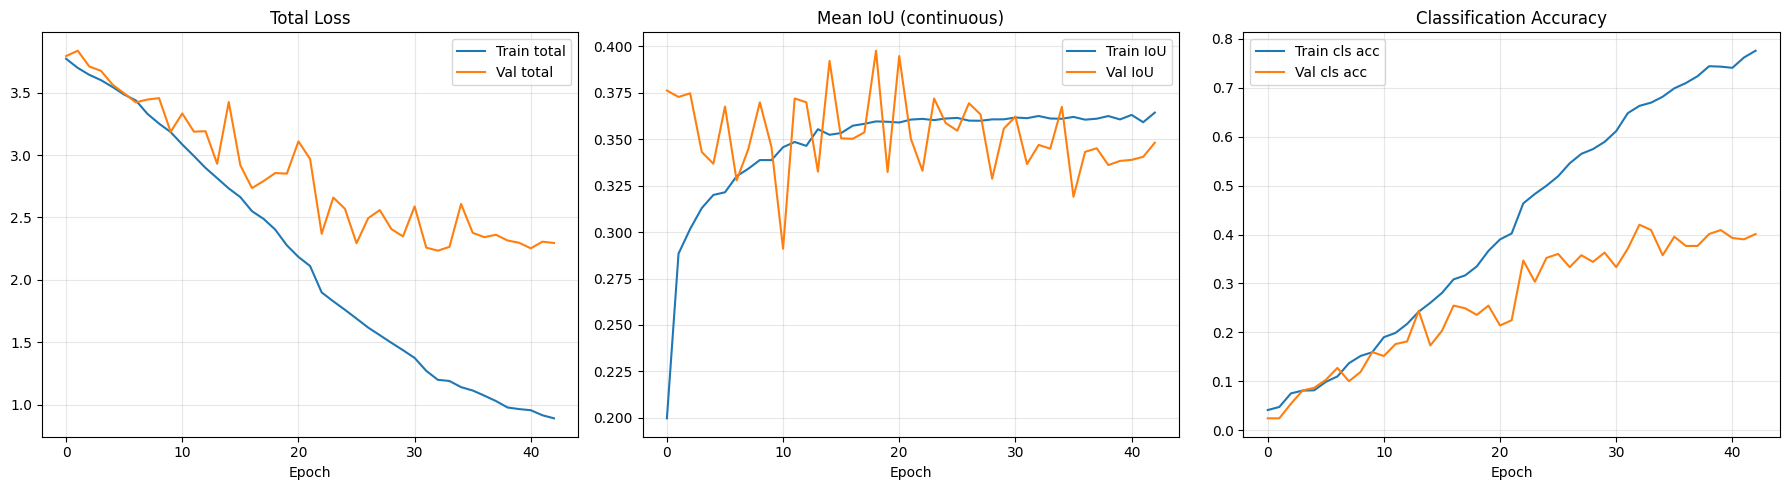

Best val cls acc: 0.42005419731140137
Best val IoU    : 0.3976880609989166


In [12]:
# ─── Training curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train total')
axes[0].plot(history.history['val_loss'], label='Val total')
axes[0].set_title('Total Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['bbox_iou_metric'],     label='Train IoU')
axes[1].plot(history.history['val_bbox_iou_metric'], label='Val IoU')
axes[1].set_title('Mean IoU (continuous)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history.history['cls_accuracy'],     label='Train cls acc')
axes[2].plot(history.history['val_cls_accuracy'], label='Val cls acc')
axes[2].set_title('Classification Accuracy'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Best val cls acc:", max(history.history['val_cls_accuracy']))
print("Best val IoU    :", max(history.history['val_bbox_iou_metric']))

In [13]:
# ─── Threshold-based evaluation (IoU threshold = 0.5) ───────────────────────

def compute_iou_batch(gt_boxes, pred_boxes):
    """Vectorised IoU for arrays of [xmin,ymin,xmax,ymax] normalised boxes."""
    x1 = np.maximum(gt_boxes[:, 0], pred_boxes[:, 0])
    y1 = np.maximum(gt_boxes[:, 1], pred_boxes[:, 1])
    x2 = np.minimum(gt_boxes[:, 2], pred_boxes[:, 2])
    y2 = np.minimum(gt_boxes[:, 3], pred_boxes[:, 3])
    inter = np.maximum(0.0, x2-x1) * np.maximum(0.0, y2-y1)
    area_gt   = (gt_boxes[:,2]-gt_boxes[:,0]) * (gt_boxes[:,3]-gt_boxes[:,1])
    area_pred = (pred_boxes[:,2]-pred_boxes[:,0]) * (pred_boxes[:,3]-pred_boxes[:,1])
    union = area_gt + area_pred - inter
    return inter / (union + 1e-7)

def evaluate_detection(model, X, yb, yl, iou_thresh=0.5):
    preds = model.predict(X, batch_size=32, verbose=1)
    pred_boxes   = preds['bbox']
    pred_classes = np.argmax(preds['cls'], axis=1)
    iou_scores   = compute_iou_batch(yb, pred_boxes)

    cls_correct   = (pred_classes == yl)
    iou_correct   = (iou_scores   >= iou_thresh)
    total_correct = cls_correct & iou_correct

    n = len(yl)
    return {
        'n'           : n,
        'cls_acc'     : cls_correct.sum()   / n * 100,
        'iou_acc'     : iou_correct.sum()   / n * 100,
        'total_acc'   : total_correct.sum() / n * 100,
        'mean_iou'    : iou_scores.mean()   * 100,
        'pred_classes': pred_classes,
        'pred_boxes'  : pred_boxes,
        'iou_scores'  : iou_scores,
    }

print("\n── Test-set evaluation ─────────────────────────────────────────────")
results = evaluate_detection(model, X_test, yb_test, yl_test,
                             iou_thresh=IOU_THRESHOLD)
n = results['n']

print(f"  Samples evaluated    : {n}")
print(f"  Classification Acc   : {results['cls_acc']:.2f}%  "
      f"({int(results['cls_acc']*n/100)} / {n} correct)")
print(f"  IoU Acc (>= {IOU_THRESHOLD})     : {results['iou_acc']:.2f}%  "
      f"({int(results['iou_acc']*n/100)} / {n} correct)")
print(f"  Total Acc (cls & bb) : {results['total_acc']:.2f}%  "
      f"({int(results['total_acc']*n/100)} / {n} correct)")
print(f"  Mean IoU             : {results['mean_iou']:.2f}%")


── Test-set evaluation ─────────────────────────────────────────────
116/116 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step
  Samples evaluated    : 3688
  Classification Acc   : 32.32%  (1191 / 3688 correct)
  IoU Acc (>= 0.5)     : 3.99%  (147 / 3688 correct)
  Total Acc (cls & bb) : 1.55%  (56 / 3688 correct)
  Mean IoU             : 26.47%


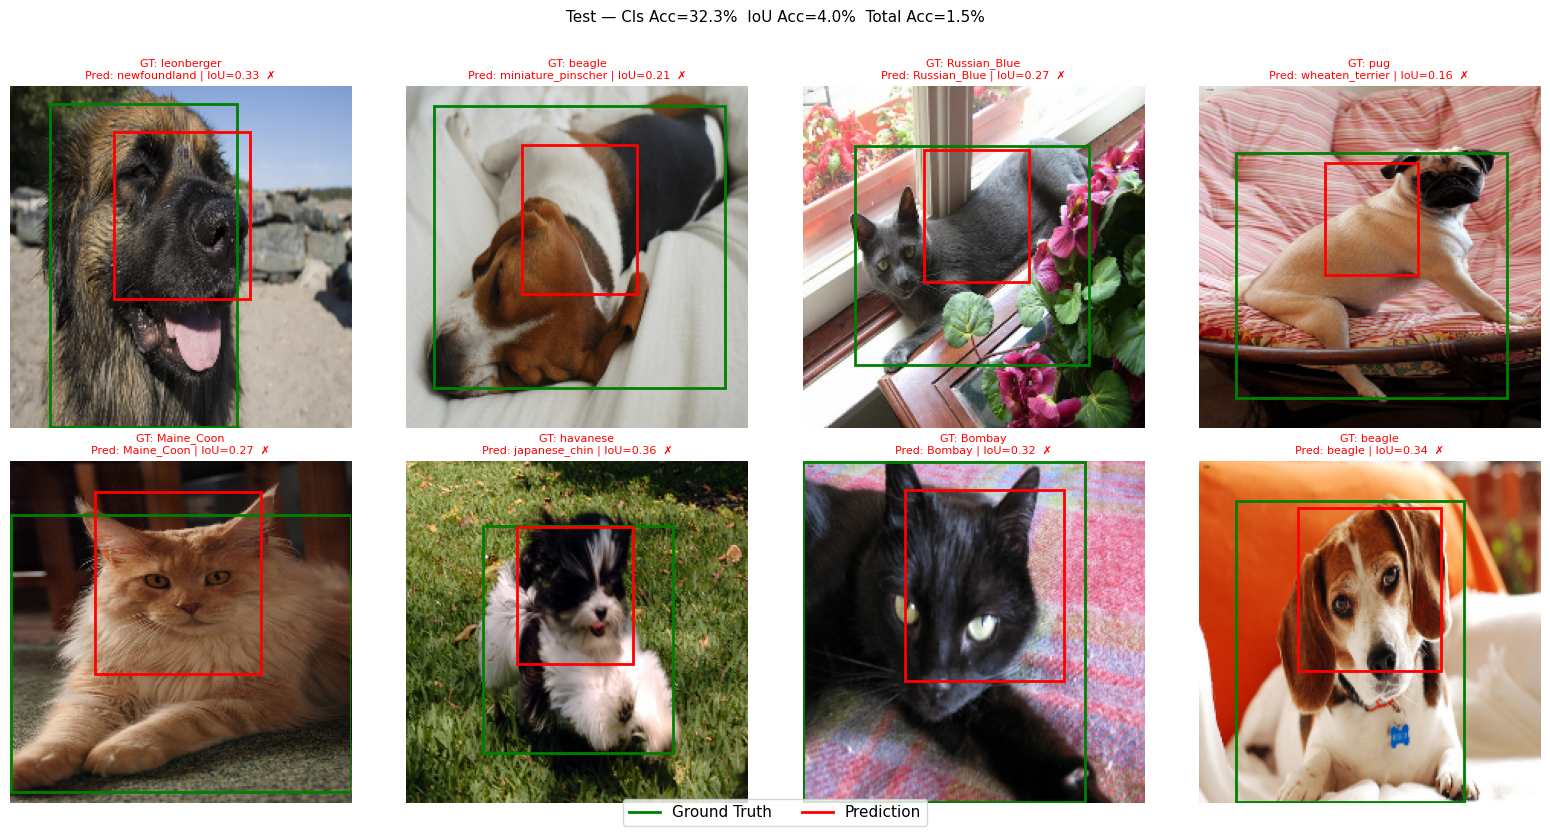

Saved: predictions.png


In [14]:
# ─── Visualise predictions on test set ───────────────────────────────────────
def visualise_predictions(model, X_test, yb_test, yl_test,
                          iou_thresh=0.5, n_samples=8):
    indices = np.random.choice(len(X_test), n_samples, replace=False)
    imgs    = X_test[indices]
    gt_b    = yb_test[indices]
    gt_l    = yl_test[indices]

    preds   = model.predict(imgs, verbose=0)
    pb      = preds['bbox']
    pc      = np.argmax(preds['cls'], axis=1)

    cols = 4; rows = (n_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()

    for i in range(n_samples):
        ax = axes[i]; ax.imshow(imgs[i]); ax.axis('off')
        h = w = IMG_SIZE
        g = gt_b[i]; p = pb[i]

        ax.add_patch(patches.Rectangle(
            (g[0]*w, g[1]*h), (g[2]-g[0])*w, (g[3]-g[1])*h,
            lw=2, edgecolor='green', facecolor='none'))
        ax.add_patch(patches.Rectangle(
            (p[0]*w, p[1]*h), (p[2]-p[0])*w, (p[3]-p[1])*h,
            lw=2, edgecolor='red', facecolor='none'))

        ix = max(g[0],p[0]); iy = max(g[1],p[1])
        ax2= min(g[2],p[2]); ay2= min(g[3],p[3])
        inter = max(0,ax2-ix)*max(0,ay2-iy)
        union = (g[2]-g[0])*(g[3]-g[1])+(p[2]-p[0])*(p[3]-p[1])-inter
        iou   = inter/(union+1e-7)

        cls_ok = (pc[i]==gt_l[i]); iou_ok = (iou>=iou_thresh)
        status = "✓" if (cls_ok and iou_ok) else "✗"
        col    = 'green' if (cls_ok and iou_ok) else 'red'

        ax.set_title(
            f"GT: {id_to_class[gt_l[i]]}\nPred: {id_to_class[pc[i]]} | IoU={iou:.2f}  {status}",
            fontsize=8, color=col)

    for ax in axes[n_samples:]: ax.set_visible(False)

    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Line2D([0],[0], color='green', lw=2, label='Ground Truth'),
        Line2D([0],[0], color='red',   lw=2, label='Prediction'),
    ], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5,-0.02))

    plt.suptitle(
        f"Test — Cls Acc={results['cls_acc']:.1f}%  "
        f"IoU Acc={results['iou_acc']:.1f}%  "
        f"Total Acc={results['total_acc']:.1f}%",
        fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: predictions.png")

visualise_predictions(model, X_test, yb_test, yl_test,
                      iou_thresh=IOU_THRESHOLD, n_samples=8)